# Visualizing the data captured
This script will allow you to visualise the data you captured (or were given). At the end you will have a 1D plot (in other words the Range FFT) giving you the change in frequencies in the x axis and the power at which those frequencies are on the y axis. The change (or delta) in frequencies will enable you to estimate the range at which the object was from the radar, whereas the power allows you to understand the strength of the reflector. The strength can be impacted by many things such as the material (something like metal will reflect much more of the signal than something like plastic), the size, and shape of the reflector!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy
import scipy.io as sio
import sys

sys.path.append(os.path.dirname(os.getcwd()))

import utils.save_adc_data as sd
import utils.utility as utility

%load_ext autoreload
%autoreload 2

## Finding your way to the data
This part allow you to specify where all the **data** is located in your file system, relative to where this file (visualize_data.ipynb) is saved.
* *filename* must correspond to the name of the **experiment** you made (it is the same as the one you had to setup in the config file)
* *capture_data_dir* must correspond to the folder were you stored the **raw data** captured by the radar (aka the *.bin file)
* *json_filename* correspond to the the json file that we provide for you, it describes the paramters that you captured the data, such as number of frames, number of transmitters, number of receivers, number of ADC samples, etc. 
* *config_lua_script* is the configuration lua script (same as capture_data.ipynb)

**IMPORTANT NOTE** 
If you decide to change something about the chirp parameters (primarily number of Tx, number of Rx, or ADC samples) then you must do some extra edits below to reformat the data accordingly. Otherwise leave the defaults.




In [14]:

filename = r"highres_rat_setup-jerry_take-1_fs-2420_slp-62-474_N-128_Raw_0"
home_dir = r"D:/GitHub/COM-304-Rat-Detection"
capture_data_dir = r"data/rat-data/rat-raw"
json_filename = r"scripts/chirp1"
config_lua_script = r'scripts/1843_config.lua' 


path_to_rawdata = os.path.join(home_dir,capture_data_dir,"rdc_" + filename + '.mat')
if os.path.exists(os.path.join(home_dir,capture_data_dir,"rdc_" + filename + '.mat')):
    bin_data = sio.loadmat(os.path.join(home_dir,capture_data_dir,"rdc_" + filename + '.mat'))

# this function reads the parameters from your lua config file (look at this function to see how it expects your config file to be formatted)
chirp_dict = utility.read_radar_params(os.path.join(home_dir,config_lua_script))

tx_en = '0x7' # HEX enable (1 for on, 0 for off)
rx_en = '0xF' # HEX enable (1 for on, 0 for off)

args = [chirp_dict['num_tx'], chirp_dict['num_rx'], chirp_dict['samples_per_chirp'], chirp_dict['chirp_loops'], tx_en, rx_en]

This cells calls to another script that you have called save_adc_data, located in the **processing** folder. What this script does it reformating the data, which is a binary file, to a more understandable format which it a .mat {}

In [15]:
############################# Reformat the Data #############################
if not os.path.exists(os.path.join(home_dir,capture_data_dir,"rdc_" + filename + '.mat')):
    sd.save_adc_data(filename, home_dir, capture_data_dir, json_filename,args)

D:/GitHub/COM-304-Rat-Detection\data/rat-data/rat-raw\raw_highres_rat_setup-jerry_take-1_fs-2420_slp-62-474_N-128_Raw_0
D:/GitHub/COM-304-Rat-Detection\data/rat-data/rat-raw\rdc_highres_rat_setup-jerry_take-1_fs-2420_slp-62-474_N-128_Raw_0


TypeError: string indices must be integers, not 'str'

In [4]:
################################# load data #################################
bin_data = sio.loadmat(os.path.join(home_dir,capture_data_dir,"rdc_" + filename + '.mat'))
raw_data = np.array(bin_data['data_raw'])

print("You captured %d frames, for %d TX, %d Rx, and %d adc samples" % raw_data.shape)

You captured 15 frames, for 4 TX, 4 Rx, and 512 adc samples


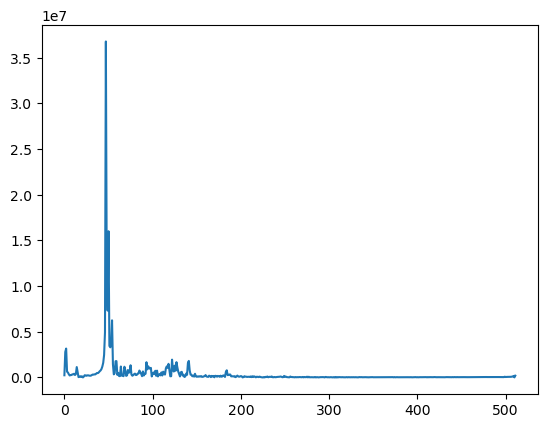

In [5]:
############################### process data! ################################
# Range FFT
rfft = scipy.fft.fft(raw_data, axis=3)

# Plot the Range FFT
plt.plot(abs(np.squeeze(np.sum(rfft,axis=(0,2,1)))))


In [6]:
binfile = "task3_gt_Raw_0.bin"
binpath = os.path.join(home_dir,capture_data_dir,binfile)

size = os.path.getsize(binpath)
print(f"File size: {size / 1e6:.2f} MB")

data = np.fromfile(binpath, dtype=np.int16)
print(f"Total int16 samples: {len(data)}")
print(f"First 20 values: {data[:20]}")
print(f"Mean: {data.mean():.2f}, Std: {data.std():.2f}")

File size: 3.07 MB
Total int16 samples: 1536000
First 20 values: [ 1583 -1892  3296  3269   895  2772 -3098 -1250 -2492 -3492  2768  -612
  2795  2363  -510  2152 -3315  -850 -1351 -3338]
Mean: 5.43, Std: 1861.47


In [7]:
import numpy as np

# Your radar params from the lua config - fill these in
# Common IWR1843 config values:
num_tx = 3
num_rx = 4
samples_per_chirp = 256  # ADC samples
chirp_loops = 1        # chirps per frame (num_doppler_bins)

num_virtual_ant = num_tx * num_rx  # 12

samples_per_frame = num_virtual_ant * samples_per_chirp * chirp_loops * 2  # *2 for I+Q
print(f"Expected samples per frame: {samples_per_frame}")
print(f"Total samples: {len(data)}")
print(f"Number of frames: {len(data) / samples_per_frame:.2f}")  # should be close to integer

Expected samples per frame: 6144
Total samples: 1536000
Number of frames: 250.00


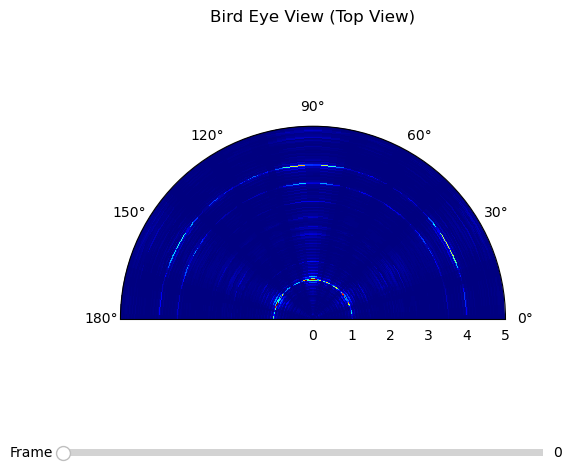

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

# --- Load and reshape bin ---
data = np.fromfile(binpath, dtype=np.int16)
num_frames, num_ant, n_samples = 250, 12, 256
raw = data.reshape(num_frames, 1, num_ant, n_samples * 2)
iq = raw[..., 0::2] + 1j * raw[..., 1::2]
iq = iq.squeeze(axis=1)  # (250, 12, 256)

# --- Range + Angle FFT ---
range_fft = np.fft.fft(iq, axis=-1)
angle_fft = np.fft.fftshift(np.fft.fft(range_fft, n=64, axis=1), axes=1)
power_cube = np.abs(angle_fft)  # (250, 64, 256)

# --- Setup axes using your viz functions ---
sys.path.append(os.path.dirname(os.getcwd()))
from streaming_base.visualization import visualization  # adjust import to your file name

phi = np.linspace(0, np.pi, 64)   # 0 to 180 degrees in radians
r   = np.linspace(0, 5.0, 256)    # 0 to ~5m, adjust to your max range

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(8, 5))
im = visualization.configure_ax_bf(ax, phi, r, vmin=0, vmax=power_cube.max() * 0.3)

# --- Scrub through frames with a slider ---
from matplotlib.widgets import Slider

ax_slider = fig.add_axes([0.2, 0.02, 0.6, 0.03])
slider = Slider(ax_slider, 'Frame', 0, num_frames - 1, valinit=0, valstep=1)

def update(val):
    frame = int(slider.val)
    im.set_array(power_cube[frame].ravel())
    fig.canvas.draw_idle()

slider.on_changed(update)
update(0)
#plt.tight_layout()
plt.show()

In [16]:
sys.path.append(os.path.dirname(os.getcwd()))
from streaming_base.gtrack.config import GTrackConfig2D, PresenceZone2D, Detection
from streaming_base.gtrack.module import GTrackModule2D
from streaming_base.visualization.visualization import configure_ax_bf, configure_ax_gtrack, update_ax_gtrack

# ─── Radar params ─────────────────────────────────────────────────────
NUM_TX, NUM_RX  = 3, 4
NUM_ANT         = NUM_TX * NUM_RX
ADC_SAMPLES     = 256
NUM_FRAMES      = 250
SAMPLE_RATE     = 5000e3
FREQ_SLOPE      = 64.598e12
RANGE_RES       = (3e8 * SAMPLE_RATE) / (2 * FREQ_SLOPE * ADC_SAMPLES)
MAX_RANGE       = RANGE_RES * ADC_SAMPLES
print(f"Range res: {RANGE_RES:.3f}m  Max range: {MAX_RANGE:.2f}m")

# ─── GTrack config — tuned for small fast animals ─────────────────────
cfg = GTrackConfig2D(
    max_points          = 50,
    max_tracks          = 5,           # max simultaneous rodents
    dt                  = 0.02,        # 20ms from lua PERIODICITY
    process_noise       = 0.5,         # higher = trust measurements more (fast animals)
    meas_noise_range    = 0.05,        # 5cm range noise
    meas_noise_az       = 0.05,        # ~3deg azimuth noise
    gating_threshold    = 9.21,        # chi-squared 2DOF 99%
    alloc_range_gate    = 0.5,         # 50cm clustering gate
    alloc_az_gate       = 0.2,         # ~11deg clustering gate
    alloc_vel_gate      = 2.0,         # 2m/s — rodents are fast
    min_cluster_points  = 2,           # low — small radar cross section
    alloc_snr_threshold = 5.0,         # low — through wall attenuates signal
    min_snr_threshold   = 3.0,
    init_state_cov      = 1.0,
    det_to_active_count = 3,           # confirm track after 3 hits
    det_to_free_count   = 3,           # lose track after 3 misses
    act_to_free_count   = 5,
    presence_zones      = [PresenceZone2D(x_min=-3, x_max=3,
                                          y_min=0,  y_max=MAX_RANGE)],
    pres_on_count       = 3,
    pres_off_count      = 10,
)

# ─── Load & reshape bin ───────────────────────────────────────────────
data = np.fromfile(binpath, dtype=np.int16)
raw  = data.reshape(NUM_FRAMES, 1, NUM_ANT, ADC_SAMPLES * 2)
iq   = (raw[..., 0::2] + 1j * raw[..., 1::2]).squeeze(axis=1)  # (250,12,256)

# ─── Beamform ─────────────────────────────────────────────────────────
N_ANGLE    = 64
range_fft  = np.fft.fft(iq, n=ADC_SAMPLES, axis=-1)
angle_fft  = np.fft.fftshift(np.fft.fft(range_fft, n=N_ANGLE, axis=1), axes=1)
power_cube = np.abs(angle_fft)                                  # (250,64,256)

phi = np.linspace(0, np.pi, N_ANGLE)       # radians 0-180
r   = np.linspace(0, MAX_RANGE, ADC_SAMPLES)

# ─── Static clutter removal (kills wall return) ───────────────────────
background  = power_cube.mean(axis=0, keepdims=True)
power_clean = np.clip(power_cube - background, 0, None)

# ─── CFAR (1D along range per angle bin) ──────────────────────────────
def cfar_1d(row, guard=2, train=8, threshold_db=10):
    hits = []
    N = len(row)
    for i in range(train + guard, N - train - guard):
        left  = row[i - train - guard : i - guard]
        right = row[i + guard + 1     : i + guard + train + 1]
        noise = np.mean(np.concatenate([left, right]))
        if noise > 0 and 10 * np.log10(row[i] / (noise + 1e-9)) > threshold_db:
            hits.append(i)
    return hits

# ─── Run tracker over all frames (pre-compute so slider is smooth) ────
tracker    = GTrackModule2D(cfg)
all_tracks = []

for f in range(NUM_FRAMES):
    power_map  = power_clean[f]     # (64, 256)
    detections = []

    for a_idx in range(N_ANGLE):
        noise_floor = background[0, a_idx, :]
        for r_idx in cfar_1d(power_map[a_idx]):
            snr = power_map[a_idx, r_idx] / (noise_floor[r_idx] + 1e-9)
            if snr < cfg.min_snr_threshold:
                continue
            detections.append(Detection(
                r   = float(r[r_idx]),
                az  = float(phi[a_idx] - np.pi / 2),  # centre 0 = boresight
                v   = 0.0,                              # no doppler (chirp_loops=1)
                snr = float(snr),
            ))

    result = tracker.step(detections)
    all_tracks.append(result['tracks'])

active_frames = sum(1 for t in all_tracks if t)
print(f"Tracking done. {active_frames}/{NUM_FRAMES} frames with active tracks")

# ─── Interactive replay ───────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))
ax_bf     = fig.add_subplot(1, 2, 1, projection='polar')
ax_gtrack = fig.add_subplot(1, 2, 2)

vmax = np.percentile(power_clean, 99.5)
im   = configure_ax_bf(ax_bf, phi, r, vmin=0, vmax=vmax)
configure_ax_gtrack(ax_gtrack, width=5.0, rgd=MAX_RANGE)

last_artists = []

ax_slider = fig.add_axes([0.2, 0.02, 0.6, 0.03])
slider    = Slider(ax_slider, 'Frame', 0, NUM_FRAMES - 1, valinit=0, valstep=1)

def update(val):
    f = int(slider.val)
    im.set_array(power_clean[f].ravel())
    update_ax_gtrack(ax_gtrack, all_tracks[f], last_artists)
    n = len(all_tracks[f])
    fig.suptitle(f"Frame {f}/{NUM_FRAMES-1}  |  Active tracks: {n}")
    fig.canvas.draw_idle()

slider.on_changed(update)
update(0)
plt.tight_layout()
plt.show()

Range res: 0.045m  Max range: 11.61m


C:\Users\janva\AppData\Local\Temp\ipykernel_20164\752067296.py:68: RuntimeWarning: divide by zero encountered in log10
  if noise > 0 and 10 * np.log10(row[i] / (noise + 1e-9)) > threshold_db:
C:\Users\janva\AppData\Local\Temp\ipykernel_20164\752067296.py:68: RuntimeWarning: divide by zero encountered in log10
  if noise > 0 and 10 * np.log10(row[i] / (noise + 1e-9)) > threshold_db:


KeyboardInterrupt: 

# RAT DETECTION TESTING

In [9]:
# setup
filename = r""
home_dir = r"D:/GitHub/COM-304-Rat-Detection"

raw_pipe_capture_data_dir = r"data/pipe-data/20-4-26/pipe-raw"
full_pipe_capture_data_dir = r"data/pipe-data/20-4-26/full-pip"
json_filename = r"scripts/chirp1"
config_lua_script = r'scripts/1843_config_highres.lua' 


def create_file_path(data_dir, filename):
    path = os.path.join(home_dir, data_dir, "rdc_" + filename + '.mat')
    return path


def save_adc_data(path, filename, home_dir, data_dir, json_filename, args):
    if not os.path.exists(path):
        sd.save_adc_data(filename, home_dir, data_dir, json_filename,args)

def load_adc_data(path):
    bin_data = sio.loadmat(path)
    raw_data = np.array(bin_data['data_raw'])
    return raw_data

def read_lua_config(lua):
    # this function reads the parameters from your lua config file (look at this function to see how it expects your config file to be formatted)
    print(home_dir, lua)
    lua_path = os.path.join(home_dir, lua)
    print(f"Reading Lua config from: {lua_path}")
    chirp_dict = utility.read_radar_params(lua_path)

    tx_en = '0x7' # HEX enable (1 for on, 0 for off)
    rx_en = '0xF' # HEX enable (1 for on, 0 for off)

    args = [chirp_dict['num_tx'], chirp_dict['num_rx'], chirp_dict['samples_per_chirp'], chirp_dict['chirp_loops'], tx_en, rx_en]

    return args


In [10]:
args = read_lua_config(config_lua_script)

# read raw rat data
raw_rat_capture_data_dir = r"data/rat-data/20-4-26/rat-raw"

jerry_path = create_file_path(raw_rat_capture_data_dir, "highres_rat_setup-jerry_take-1_fs-2420_slp-62-474_N-128_Raw_0.bin")
if os.path.exists(jerry_path):
    jerry_bin = sio.loadmat(jerry_path)
save_adc_data(jerry_path, "highres_rat_setup-jerry_take-1_fs-2420_slp-62-474_N-128_Raw_0", home_dir, raw_rat_capture_data_dir, json_filename, args)
jerry_raw = load_adc_data(jerry_path)


mike_path = create_file_path(raw_rat_capture_data_dir, "highres_rat_setup-michael_take-1_fs-2420_slp-62-474_N-128_Raw_0.bin")
if os.path.exists(mike_path):
    mike_bin = sio.loadmat(mike_path)
save_adc_data(mike_path, "highres_rat_setup-michael_take-1_fs-2420_slp-62-474_N-128_Raw_0", home_dir, raw_rat_capture_data_dir, json_filename, args)
mike_raw = load_adc_data(mike_path)





D:/GitHub/COM-304-Rat-Detection scripts/1843_config_highres.lua
Reading Lua config from: D:/GitHub/COM-304-Rat-Detection\scripts/1843_config_highres.lua
D:/GitHub/COM-304-Rat-Detection\data/rat-data/20-4-26/rat-raw\raw_highres_rat_setup-jerry_take-1_fs-2420_slp-62-474_N-128_Raw_0
D:/GitHub/COM-304-Rat-Detection\data/rat-data/20-4-26/rat-raw\rdc_highres_rat_setup-jerry_take-1_fs-2420_slp-62-474_N-128_Raw_0


TypeError: string indices must be integers, not 'str'